# sc-TCR_seq

In [107]:
## Import libraries
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad
import pandas as pd
from scipy.stats import wilcoxon
import scirpy as ir
import mudata as mu
import muon as mu
import gseapy as gp

In [68]:
## Setting verbosity and figure parameters
sc.settings.verbosity = 0 
sc.settings.set_figure_params(
    dpi = 80,
facecolor = "white",
frameon = True,
)

In [69]:
## Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [70]:
## Import data
mdata = mu.read("/mnt/projects/labs/Covid-19/mdata_filtered.h5mu")

**TCR QC**

In [71]:
## Create chain indices
ir.pp.index_chains(mdata)
mdata['airr'].obsm['chain_indices']

<Array [{VJ: [2, 0], VDJ: [...], ...}, ...] type='13087 * {VJ: 2 * ?int64, ...'>

In [72]:
## Retrieve the "locus" field of the primary VJ chain for each cell
ir.get.airr(mdata, "locus", "VJ_1")

cell_id
AAACCTGAGATAGGAG-1-0     TRA
AAACCTGGTGTCCTCT-1-0     TRA
AAACGGGAGATCACGG-1-0     TRA
AAACGGGAGTCCATAC-1-0     TRA
AAACGGGCATCACCCT-1-0     TRA
                        ... 
TTTATGCGTCAACATC-1-12    TRA
TTTGCGCAGTGGCACA-1-12    TRA
TTTGGTTAGGGATGGG-1-12    TRA
TTTGGTTGTAGAAGGA-1-12    TRA
TTTGTCATCAGTACGT-1-12    TRA
Length: 13087, dtype: object

In [73]:
## TCR quality control
ir.tl.chain_qc(mdata)

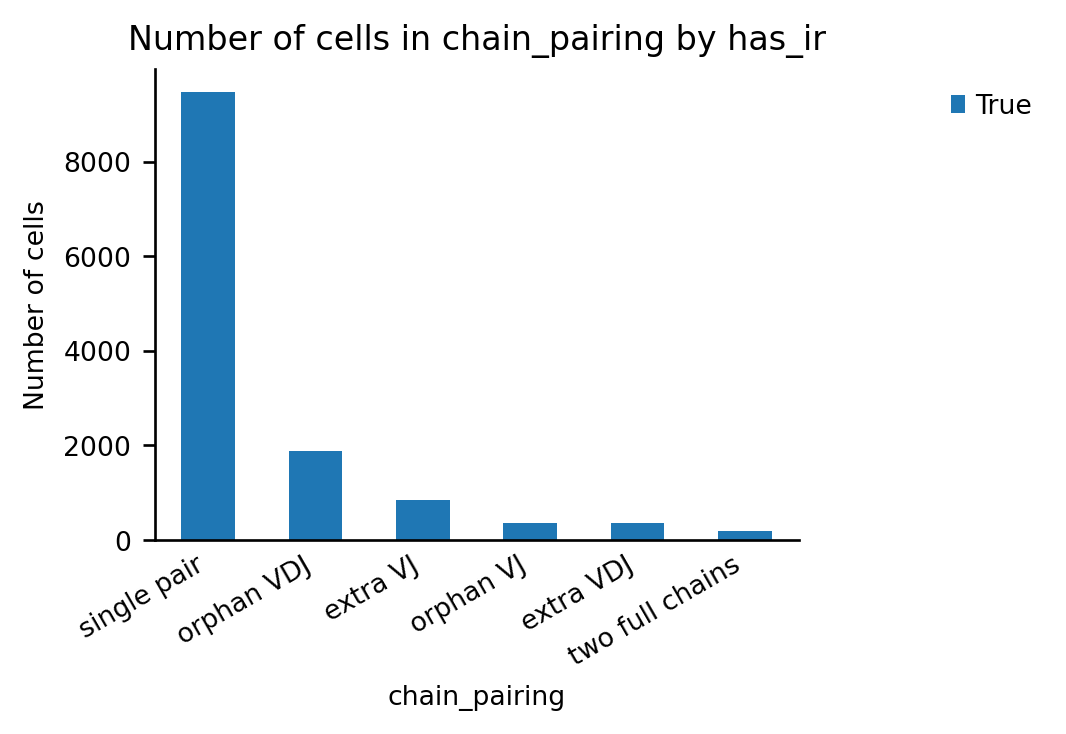

In [74]:
## Check chain pairing 
_ = ir.pl.group_abundance(mdata['airr'], groupby="chain_pairing")

In [75]:
## Keep just single pair and extra VJ chain
mu.pp.filter_obs(mdata, "airr:chain_pairing", lambda x: ~np.isin(x, ["orphan VDJ", "orphan VJ"]))
mu.pp.filter_obs(mdata, "airr:chain_pairing", lambda x: ~np.isin(x, ["extra VDJ", "two full chains"]))

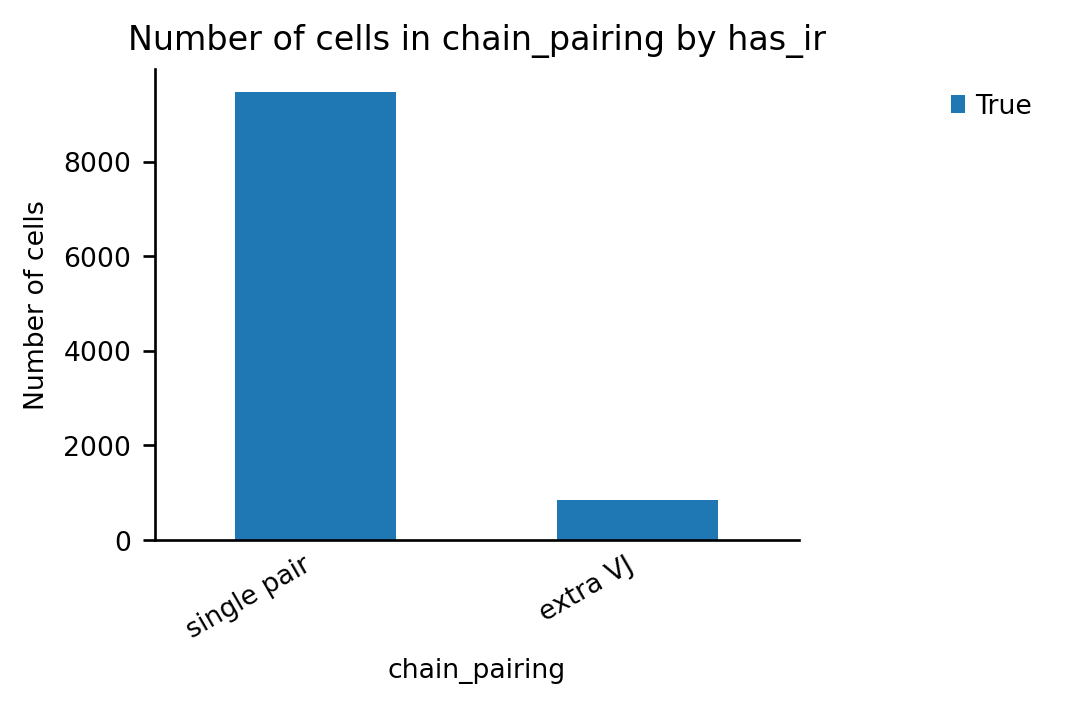

In [76]:
## Check chain pairing after filters
_ = ir.pl.group_abundance(mdata['airr'], groupby="chain_pairing")

**Define clonotypes**

In [77]:
## The function computes a sequence-distance metric between all unique VJ CDR3 sequences and between
## all unique VDJ CDR3 sequences
ir.pp.ir_dist(mdata)

In [78]:
## Define clonotypes based on CDR3 nucleic acid sequence identity
ir.tl.define_clonotypes(mdata)

  0%|          | 0/6311 [00:00<?, ?it/s]

In [79]:
## Create the network of clonotypes to visualize
## min_cells >= 2 to prevent the singleton clonotypes from cluttering the network
ir.tl.clonotype_network(mdata, min_cells=2)

<Axes: >

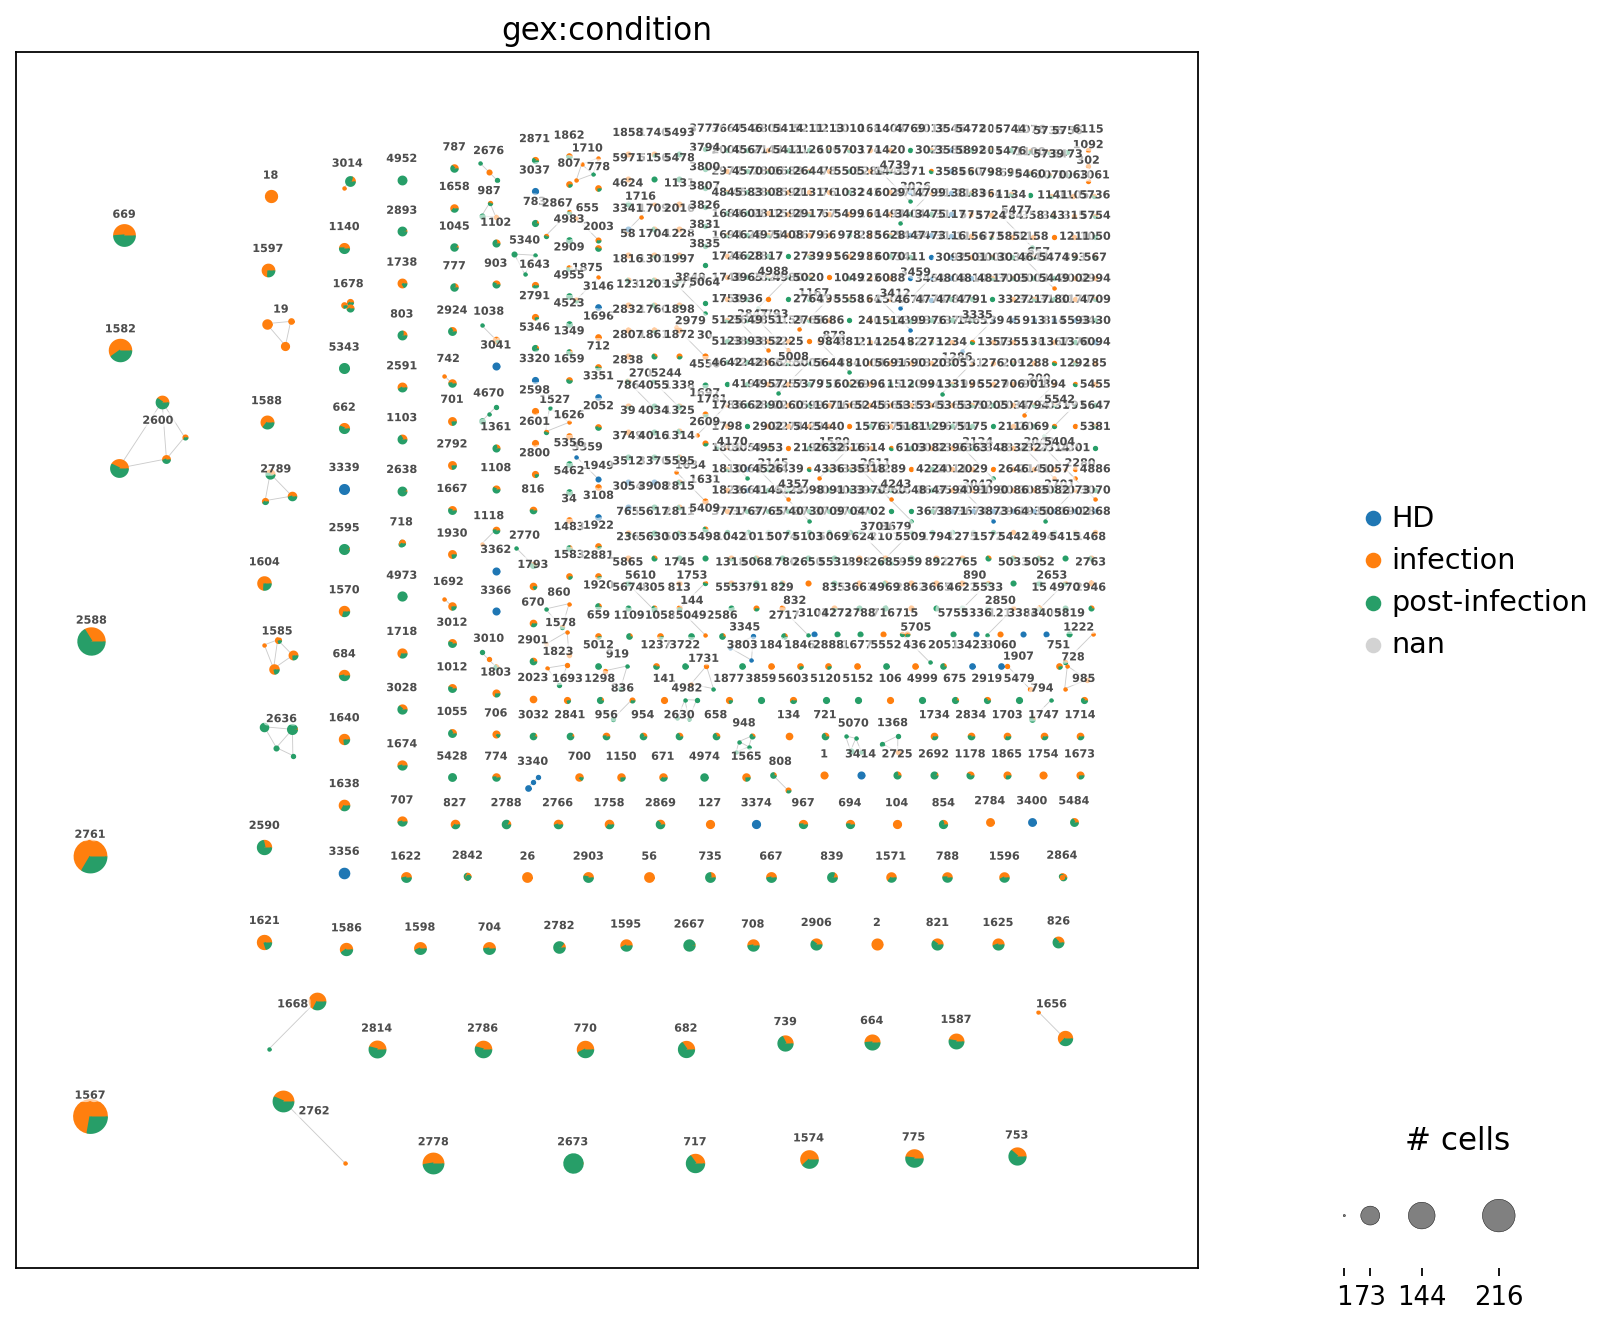

In [80]:
## Visualize the clonotypes
ir.pl.clonotype_network(mdata, color='gex:condition', base_size=1, label_fontsize=5, panel_size=(10, 10),
                            scale_by_n_cells = True)

**Clonotypes analysis**

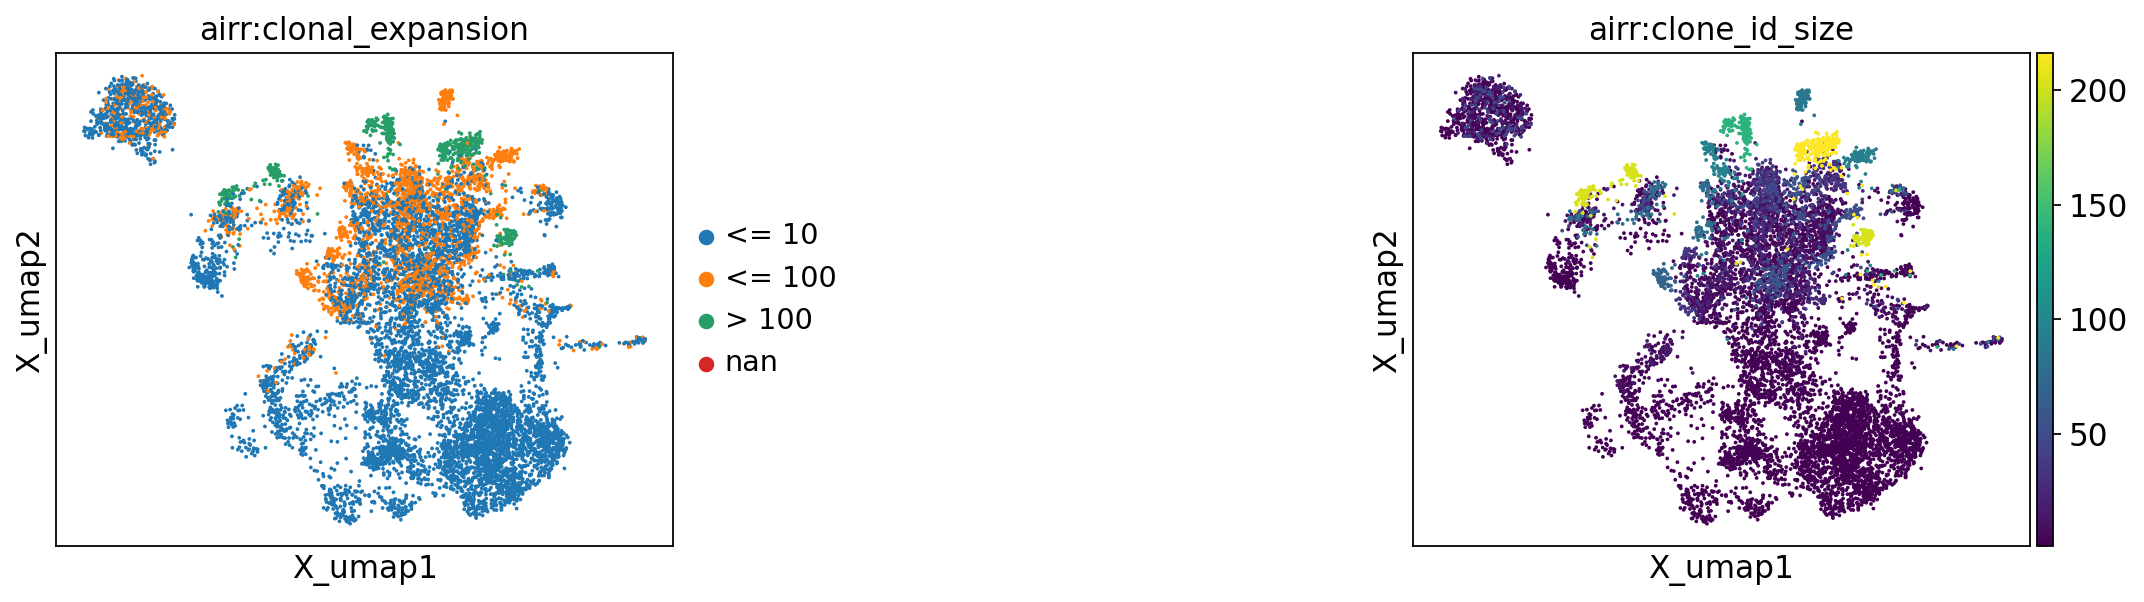

In [81]:
ir.tl.clonal_expansion(mdata, breakpoints=(10,100))
mu.pl.embedding(mdata, basis="gex:umap", color=["airr:clonal_expansion", "airr:clone_id_size"], wspace=1)

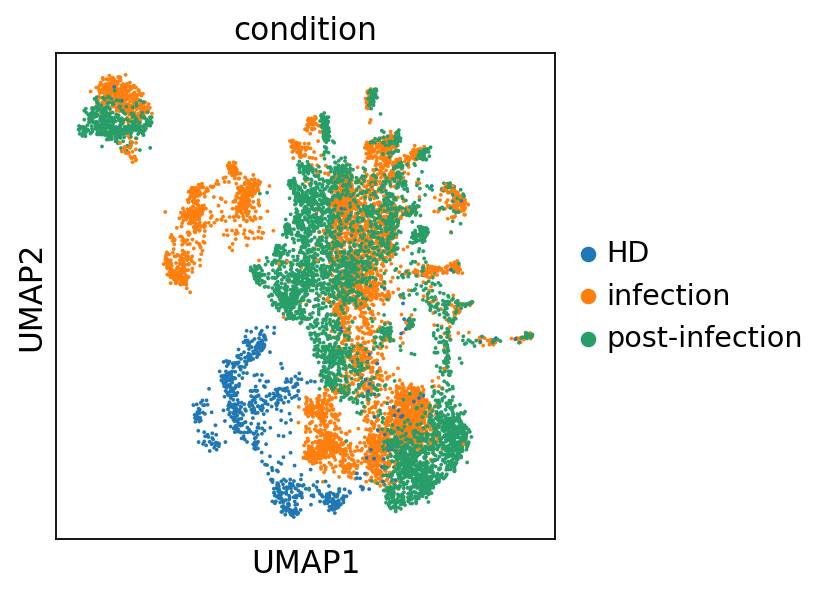

In [82]:
## UMAPS
sc.pl.umap(mdata['gex'], color ='condition')

**Transient e persistent clones**

In [83]:
## Number of effector clones just in patient 12,13,15,16 that have both conditions infection and post-infection
mdata = mdata[(mdata.obs['gex:patient'] == '12')|(mdata.obs['gex:patient'] == '13')|
              (mdata.obs['gex:patient'] == '15')|
              (mdata.obs['gex:patient'] == '16')]

In [84]:
## Classify clones in transient (present just in infection phase) and persistent (present both in infection and persistent phase)
gex_obs = mdata.mod['gex'].obs
clone_conditions = pd.DataFrame({'clone_id': mdata.mod['airr'].obs['clone_id'],
                                 'condition': gex_obs['condition']})

clone_condition_sets = clone_conditions.groupby('clone_id')['condition'].unique()

def classify_clonotype(conds):
    conds = set(conds)
    if 'infection' in conds and 'post-infection' in conds:
        return 'persistent'
    elif 'infection' in conds:
        return 'transient'
    else:
        return 'other' 

clonotype_labels = clone_condition_sets.apply(classify_clonotype)
clone_id_to_clonotype = clonotype_labels.to_dict()
mdata.obs['clonotypes'] = mdata.mod['airr'].obs['clone_id'].map(clone_id_to_clonotype)

In [85]:
## Select just cells in infection phase
mdata = mdata[mdata.obs['gex:condition'] == 'infection']

In [86]:
## Define effector clones: clones with at least one effector cell
clone_effector_map = (
    mdata.obs
    .groupby('airr:clone_id')['gex:Effector_cells']
    .apply(lambda x: (x == 'Effector').any())
)

mdata.obs['clone_effector'] = mdata.obs['airr:clone_id'].map(clone_effector_map)
mdata.obs['clone_effector'] = mdata.obs['clone_effector'].fillna(False)

## Filter just effector clones
effector_clones = mdata.obs.loc[mdata.obs['clone_effector'] == True, 'airr:clone_id'].unique()
mdata = mdata[mdata.obs['airr:clone_id'].isin(effector_clones)].copy()

## Number of unique effector clones
unique_clones_effector = mdata.obs['airr:clone_id'].nunique()
print(f"Number of unique clones: {unique_clones_effector}")


Number of unique clones: 166


**Analysis SLEC and MPEC in transient and persistent clones**

Transient clones

In [87]:
## Number of transient clones
mdata_transient_clones = mdata[(mdata.obs['clonotypes'] == 'transient')]
mdata_transient_clones.obs['airr:clone_id'].unique()

['673', '677', '838', '888', '905', ..., '6131', '6135', '6144', '6151', '6175']
Length: 121
Categories (166, object): ['669', '673', '677', '706', ..., '6135', '6144', '6151', '6175']

In [88]:
## Filter just clone_ad and cell_state
df = mdata_transient_clones.obs[['airr:clone_id', 'gex:Cell_state']].copy()
## Count the number of SLEC and MPEC for each clone
pivot = pd.crosstab(df['airr:clone_id'], df['gex:Cell_state'])

In [92]:
## SLEC clones have at least one SLEC cell
slec = pivot[(pivot['SLEC'] > 0) & (pivot['MPEC'] == 0)].index
## % of SLEC clones in transient ones
x = (len(slec)*100) / 121
print(x)

52.06611570247934


In [93]:
## MPEC clones have at least one SLEC cell
mpec = pivot[(pivot['MPEC'] > 0) & (pivot['SLEC'] == 0)].index
## % of MPEC clones in persistent ones
x = (len(mpec)*100) / 121
x

20.66115702479339

In [94]:
## MPEC and SLEC clones with at least one cell each
slec_mpec = pivot[(pivot['SLEC'] > 0) & (pivot['MPEC'] > 0)].index
## % of MPEC and SLEC clones in transient ones
x = (len(slec_mpec)*100) / 121
x

1.6528925619834711

Persistent clones

In [95]:
## Number of persistent clones
mdata_persistent_clones = mdata[(mdata.obs['clonotypes'] == 'persistent')]
mdata_persistent_clones.obs['airr:clone_id'].unique()

['669', '706', '708', '742', '839', ..., '3026', '3028', '5705', '5476', '5735']
Length: 45
Categories (166, object): ['669', '673', '677', '706', ..., '6135', '6144', '6151', '6175']

In [96]:
## Filter just clone_id and cell_state
df = mdata_persistent_clones.obs[['airr:clone_id', 'gex:Cell_state']].copy()
## Count the number of SLEC and MPEC for each clone
pivot = pd.crosstab(df['airr:clone_id'], df['gex:Cell_state'])

In [97]:
## SLEC clones have at least one SLEC cell
slec = pivot[(pivot['SLEC'] > 0) & (pivot['MPEC'] == 0)].index
## % of SLEC clones in transient ones
x = (len(slec)*100) / 45
print(x)

40.0


In [98]:
## MPEC clones have at least one SLEC cell
mpec = pivot[(pivot['MPEC'] > 0) & (pivot['SLEC'] == 0)].index
## % of MPEC clones in persistent ones
x = (len(mpec)*100) / 45
x

26.666666666666668

In [99]:
## MPEC and SLEC clones with at least one cell each
slec_mpec = pivot[(pivot['SLEC'] > 0) & (pivot['MPEC'] > 0)].index
## % of MPEC and SLEC clones in transient ones
x = (len(slec_mpec)*100) / 45
x

15.555555555555555

DEG & GSEA transient and persistent clones

In [100]:
gex_df = mdata['gex']

## Add the clonotypes column to the gex DataFrame
mdata['gex'].obs['gex:clonotypes'] = mdata.obs['clonotypes']

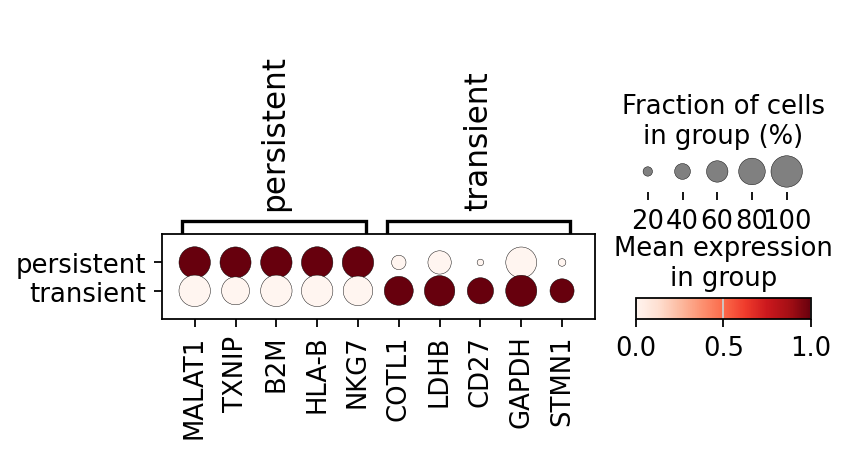

In [101]:
## Differential Expression Analysis
sc.tl.rank_genes_groups(mdata['gex'], groupby="gex:clonotypes", method="wilcoxon", pts_rest = True, pts = True)

## Dotplot
sc.pl.rank_genes_groups_dotplot(mdata['gex'], groupby="gex:clonotypes", standard_scale="var", n_genes=5)

In [103]:
merge_df = pd.DataFrame(mdata['gex'].raw.X.todense(), columns=mdata['gex'].var.index,index=(mdata['gex'].obs.index))
zscore = ((merge_df - merge_df.mean())/ merge_df.std(ddof=0))
zscore = zscore.loc[:,zscore.notna().any(axis=0)]
col = mdata['gex'].obs['gex:clonotypes']
zscore = pd.concat([zscore,col], axis = 1)

In [104]:
## Filter each cluster
cluster = zscore.loc[zscore['gex:clonotypes'] == 'persistent']
cluster = cluster.drop('gex:clonotypes', axis=1)
## Ranking the values of zscore
rank = pd.DataFrame(cluster.mean().sort_values(ascending = False))

In [105]:
marker_genes_intersection = {
 "SLEC": ["MKI67","MCM5","GBP1","RRM2","PCNA","STMN1","FABP5","CCT5","GIMAP4","TYMS","TUBB","NDUFB3","LSM5","CENPF",
          "TRAPPC1","CDK2AP2","DYNLL1","NOP10","NUDC","SNRPD3","CD38","MRPL52"],
 "MPEC":["NR4A2","SYTL3","ZNF331","CXCR4","REL","AC016831.7","JUNB","GADD45B","AKNA","PIK3R1","FOSB","IER2","RNF125","JUND",
         "SKIL","SPOCK2","RANBP2","HERPUD2","IFRD1","YPEL5","JUN","KLF6","JMJD6","PPP2R2B","ATG2A","BTG2","TENT5C","TUBA1A",
         "FOS","CD83","DUSP1","IDS"]}

In [108]:
## Prerank
pre_res = gp.prerank(rnk = rank, gene_sets = [marker_genes_intersection],seed = 6, permutation_num = 1000, min_size=3)

## Results
out = pre_res.res2d
out

2025-07-24 15:25:42,395 [WARNING] Duplicated values found in preranked stats: 8.13% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,0__MPEC,0.772326,3.121611,0.0,0.0,0.0,17/32,8.20%,CXCR4;DUSP1;SYTL3;JUNB;PPP2R2B;PIK3R1;IDS;BTG2...
1,prerank,0__SLEC,-0.929743,-2.182262,0.0,0.0,0.0,21/22,5.57%,MKI67;STMN1;TYMS;FABP5;CENPF;RRM2;PCNA;MCM5;CD...
